Датасет был самостоятельно собран с помощью Jolpica F1 API. Одно наблюдение - одна гонка Ferrari. Целевая переменная ferrari_podium принимает значение 1, если хотя бы один пилот Ferrari занял подиум, и 0 в противном случае

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ferrari_f1_dataset.csv")

In [2]:
print("Размер датасета:", df.shape)
df.info()

Размер датасета: (1124, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   season                    1124 non-null   int64  
 1   round                     1124 non-null   int64  
 2   circuit                   1124 non-null   str    
 3   country                   1124 non-null   str    
 4   best_grid                 1123 non-null   float64
 5   avg_grid                  1123 non-null   float64
 6   prev_best_finish          1048 non-null   float64
 7   avg_finish_last_3         1048 non-null   float64
 8   avg_grid_last_3           1048 non-null   float64
 9   podiums_last_5            1048 non-null   float64
 10  dnfs_last_5               1048 non-null   float64
 11  circuit_podium_rate_prev  1048 non-null   float64
 12  ferrari_podium            1124 non-null   int64  
dtypes: float64(8), int64(3), str(2)
memory usage: 

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,1124.0,1994.096085,20.539162,1950.0,1978.000000,1996.000000,2012.000000,2025.000000
round,1124.0,8.740214,5.240956,1.0,4.000000,8.000000,13.000000,24.000000
best_grid,1123.0,4.060552,3.243791,1.0,2.000000,3.000000,5.000000,22.000000
avg_grid,1123.0,6.198895,3.603598,1.0,3.500000,5.500000,8.500000,22.000000
prev_best_finish,1048.0,4.754771,4.772171,1.0,2.000000,3.000000,6.000000,31.000000
avg_finish_last_3,1048.0,4.728849,3.498878,1.0,2.000000,3.666667,6.500000,21.000000
avg_grid_last_3,1048.0,3.984256,2.413326,1.0,2.000000,3.333333,5.333333,17.333333
podiums_last_5,1048.0,2.454198,1.572143,0.0,1.000000,2.000000,4.000000,5.000000
dnfs_last_5,1048.0,2.682252,2.304265,0.0,1.000000,2.000000,4.000000,14.000000
circuit_podium_rate_prev,1048.0,0.572613,0.229627,0.0,0.494565,0.590909,0.692308,1.000000


In [4]:
target_counts = df["ferrari_podium"].value_counts()

print(target_counts)
print()
print(
    df["ferrari_podium"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ferrari_podium
1    639
0    485
Name: count, dtype: int64

ferrari_podium
1    56.85
0    43.15
Name: proportion, dtype: float64


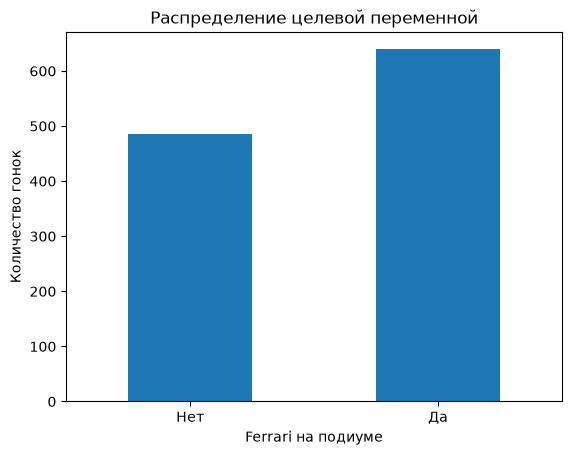

In [5]:
target_counts.sort_index().plot(kind="bar")

plt.title("Распределение целевой переменной")
plt.xlabel("Ferrari на подиуме")
plt.ylabel("Количество гонок")
plt.xticks([0, 1], ["Нет", "Да"], rotation=0)

plt.show()

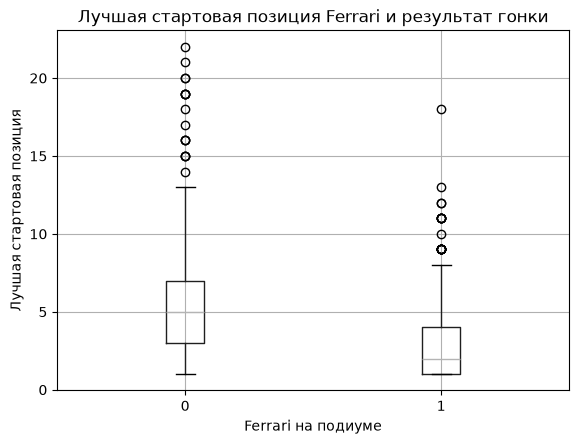

In [6]:
df.boxplot(
    column="best_grid",
    by="ferrari_podium"
)

plt.title("Лучшая стартовая позиция Ferrari и результат гонки")
plt.suptitle("")
plt.xlabel("Ferrari на подиуме")
plt.ylabel("Лучшая стартовая позиция")

plt.show()

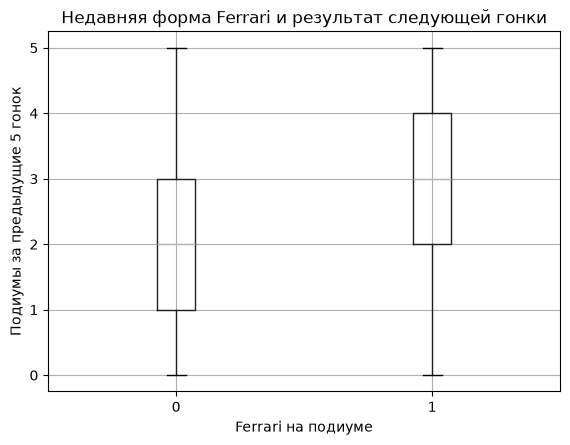

In [7]:
df.boxplot(
    column="podiums_last_5",
    by="ferrari_podium"
)

plt.title("Недавняя форма Ferrari и результат следующей гонки")
plt.suptitle("")
plt.xlabel("Ferrari на подиуме")
plt.ylabel("Подиумы за предыдущие 5 гонок")

plt.show()

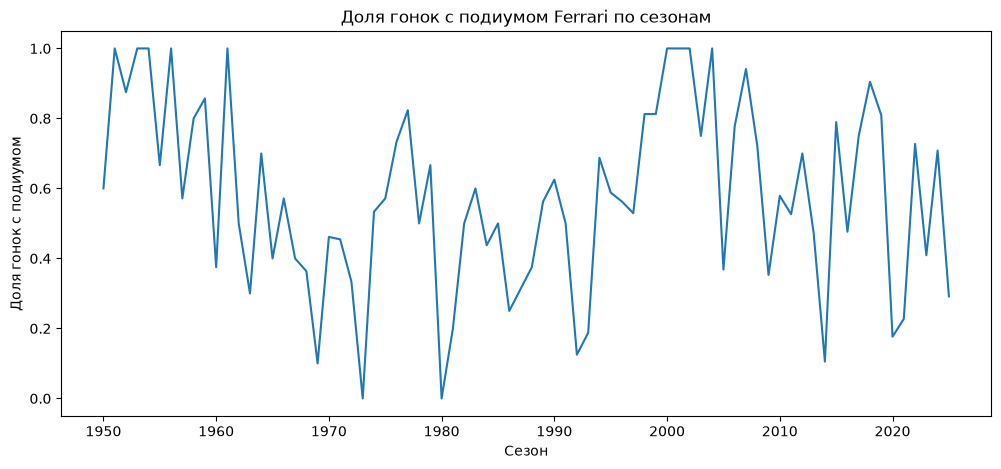

In [8]:
podium_by_season = (
    df.groupby("season")["ferrari_podium"]
    .mean()
)

podium_by_season.plot(figsize=(12, 5))

plt.title("Доля гонок с подиумом Ferrari по сезонам")
plt.xlabel("Сезон")
plt.ylabel("Доля гонок с подиумом")

plt.show()

**Пропущенные значения**
В датасете присутствуют пропущенные значения, возникающие естественным образом при отсутствии предыдущей истории. Удаление таких строк привело бы к потере данных, поэтому пропуски количественных признаков будут заполняться медианой

In [9]:
df.isna().sum()

season                       0
round                        0
circuit                      0
country                      0
best_grid                    1
avg_grid                     1
prev_best_finish            76
avg_finish_last_3           76
avg_grid_last_3             76
podiums_last_5              76
dnfs_last_5                 76
circuit_podium_rate_prev    76
ferrari_podium               0
dtype: int64

**Выбросы**
В числовых признаках имеются крайние значения, однако они соответствуют возможным ситуациям в Formula 1: низким стартовым позициям, сходам и неудачным результатам

In [10]:
outlier_features = [
    "best_grid",
    "avg_grid",
    "prev_best_finish",
    "avg_finish_last_3",
    "avg_grid_last_3",
    "dnfs_last_5"
]

for column in outlier_features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}: {len(outliers)} потенциальных выбросов")

best_grid: 78 потенциальных выбросов
avg_grid: 17 потенциальных выбросов
prev_best_finish: 96 потенциальных выбросов
avg_finish_last_3: 36 потенциальных выбросов
avg_grid_last_3: 23 потенциальных выбросов
dnfs_last_5: 20 потенциальных выбросов


**Категориальные признаки**
circuit и country являются категориальными признаками. Они не имеют естественного числового порядка, поэтому будут преобразованы методом One-Hot Encoding

In [11]:
categorical_features = [
    "circuit",
    "country"
]

for column in categorical_features:
    print(
        f"{column}: {df[column].nunique()} категорий"
    )

circuit: 76 категорий
country: 34 категорий


**Обработка данных**
В числовых признаках пропущенные значения будут заполнены медианой и нормализованы в диапазоне [0, 1]. Категориальные признаки circuit и country будут преобразованы методом One-Hot Encoding

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer


X = df.drop(columns="ferrari_podium")
y = df["ferrari_podium"]


categorical_features = [
    "circuit",
    "country"
]


numeric_features = [
    "season",
    "round",
    "best_grid",
    "avg_grid",
    "prev_best_finish",
    "avg_finish_last_3",
    "avg_grid_last_3",
    "podiums_last_5",
    "dnfs_last_5",
    "circuit_podium_rate_prev"
]


# заполнение пропусков медианой
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])


# преобразование категорий
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

**Разделение данных на выборки**
Датасет разделяется на три части:
- train (70%)
- validation (15%)
- test (15%)

При разделении используется стратификация по целевой переменной `ferrari_podium`

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (786, 12)
Validation: (169, 12)
Test: (169, 12)


In [14]:
print("Исходный датасет:")
print(y.value_counts(normalize=True).round(3))

print("\nTrain:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest:")
print(y_test.value_counts(normalize=True).round(3))

Исходный датасет:
ferrari_podium
1    0.569
0    0.431
Name: proportion, dtype: float64

Train:
ferrari_podium
1    0.569
0    0.431
Name: proportion, dtype: float64

Validation:
ferrari_podium
1    0.568
0    0.432
Name: proportion, dtype: float64

Test:
ferrari_podium
1    0.568
0    0.432
Name: proportion, dtype: float64


**Baseline-решение**
В качестве baseline используется классификатор, который всегда предсказывает наиболее часто встречающийся класс в обучающей выборке

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score


baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    y_pred_baseline
)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.568


**Обучение Random Forest**
Для решения задачи бинарной классификации выбран алгоритм Random Forest. Он представляет собой ансамбль деревьев решений и способен учитывать нелинейные зависимости между признаками

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['season','round','circuit',...,'podiums_last_5','dnfs_last_5', 'circuit_podium_rate_prev']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [17]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy:      {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")

Train accuracy:      1.000
Validation accuracy: 0.734


**Подбор гиперпараметров**
Исходная модель Random Forest показала существенную разницу между качеством на обучающей и валидационной выборках (переобучение)
Для подбора оптимальных гиперпараметров используется Grid Search

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4, 8]
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nСредняя accuracy:")
print(f"{grid_search.best_score_:.3f}")

Лучшие параметры:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Средняя accuracy:
0.735


In [19]:
best_model = grid_search.best_estimator_

y_train_pred_best = best_model.predict(X_train)
y_val_pred_best = best_model.predict(X_val)

best_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_best
)

best_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_best
)

print(f"Train accuracy:      {best_train_accuracy:.3f}")
print(f"Validation accuracy: {best_val_accuracy:.3f}")

Train accuracy:      0.800
Validation accuracy: 0.751


In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


param_grid_refined = {
    "classifier__n_estimators": [75, 100, 125],
    "classifier__max_depth": [9, 10, 11, 12],
    "classifier__min_samples_split": [8, 10, 12],
    "classifier__min_samples_leaf": [3, 4, 5]
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid_refined,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nСредняя accuracy:")
print(f"{grid_search.best_score_:.3f}")

Лучшие параметры:
{'classifier__max_depth': 9, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 75}

Средняя accuracy:
0.735


In [21]:
best_model = grid_search.best_estimator_

y_train_pred_best = best_model.predict(X_train)
y_val_pred_best = best_model.predict(X_val)

best_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_best
)

best_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_best
)

print(f"Train accuracy:      {best_train_accuracy:.3f}")
print(f"Validation accuracy: {best_val_accuracy:.3f}")

Train accuracy:      0.800
Validation accuracy: 0.751


**Оценка качества модели**

Для оценки качества модели используются метрики:
- Accuracy - показывает долю правильно классифицированных гонок
- Precision - показывает, в какой доле случаев предсказанный моделью подиум Ferrari действительно произошёл
- Recall - показывает, какую долю реальных подиумов Ferrari модель смогла обнаружить
- F1-score - объединяет Precision и Recall и характеризует баланс между ними

После подбора гиперпараметров значения метрик на обучающей, валидационной и тестовой выборках остаются достаточно близкими, что говорит об отсутствии выраженного переобучения

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

results = pd.DataFrame(
    [
        calculate_metrics(y_train, y_train_pred),
        calculate_metrics(y_val, y_val_pred),
        calculate_metrics(y_test, y_test_pred)
    ],
    index=["Train", "Validation", "Test"]
)

results.round(3)

,Accuracy,Precision,Recall,F1
Train,0.800,0.809,0.850,0.829
Validation,0.751,0.781,0.781,0.781
Test,0.728,0.750,0.781,0.765


**Анализ качества модели и влияния гиперпараметров**

 - На первом графике показано качество различных комбинаций гиперпараметров, проверенных в процессе Grid Search. Для каждой комбинации отображается средняя Accuracy, полученная при 5-кратной кросс-валидации
 - На втором графике исследуется влияние количества деревьев `n_estimators` на качество Random Forest
 - На третьем графике показано влияние максимальной глубины деревьев `max_depth`

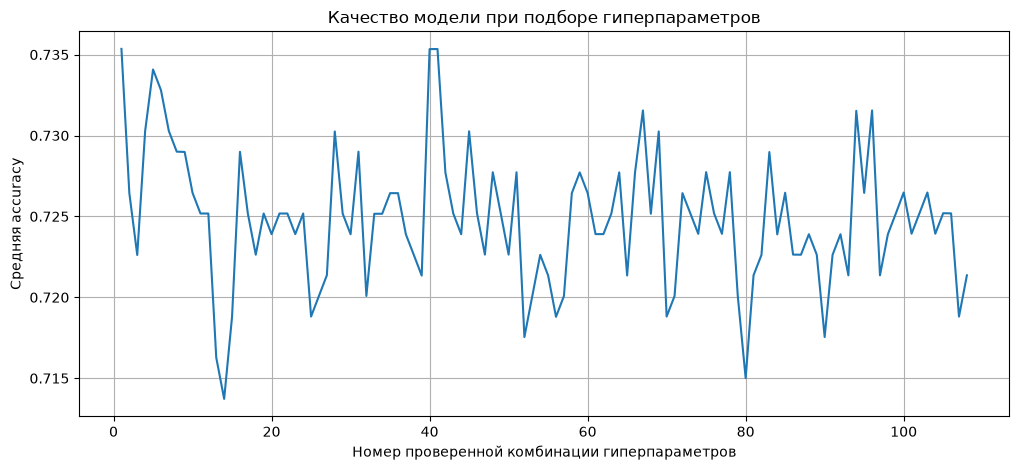

In [23]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results["iteration"] = range(1, len(cv_results) + 1)

plt.figure(figsize=(12, 5))

plt.plot(
    cv_results["iteration"],
    cv_results["mean_test_score"]
)

plt.xlabel("Номер проверенной комбинации гиперпараметров")
plt.ylabel("Средняя accuracy")
plt.title("Качество модели при подборе гиперпараметров")
plt.grid()

plt.show()

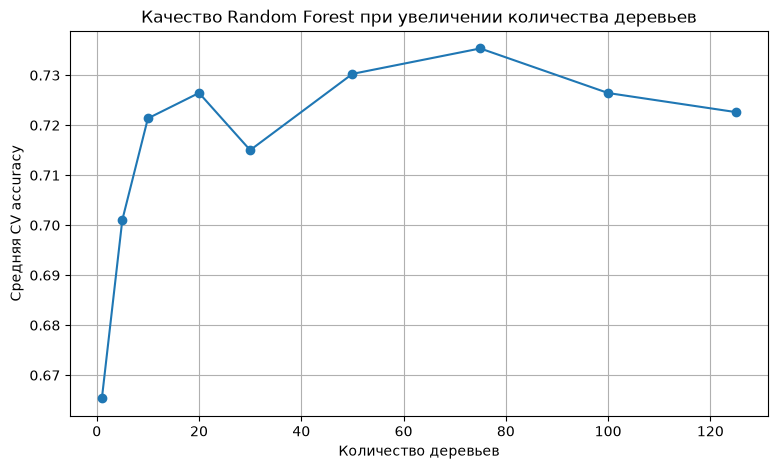

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

n_trees = [1, 5, 10, 20, 30, 50, 75, 100, 125]

mean_scores = []

for n in n_trees:
    current_model = clone(best_model)

    current_model.set_params(
        classifier__n_estimators=n
    )

    scores = cross_val_score(
        current_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_scores.append(scores.mean())

plt.figure(figsize=(9, 5))

plt.plot(
    n_trees,
    mean_scores,
    marker="o"
)

plt.xlabel("Количество деревьев")
plt.ylabel("Средняя CV accuracy")
plt.title("Качество Random Forest при увеличении количества деревьев")
plt.grid()

plt.show()

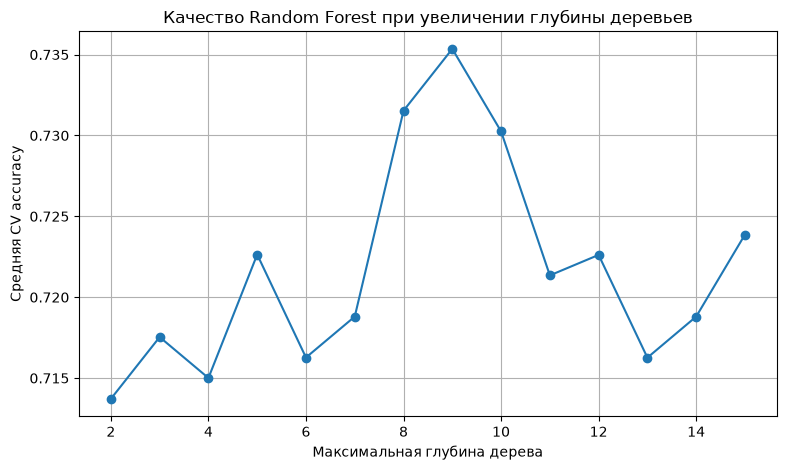

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

depths = range(2, 16)

mean_depth_scores = []

for depth in depths:
    current_model = clone(best_model)

    current_model.set_params(
        classifier__max_depth=depth
    )

    scores = cross_val_score(
        current_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_depth_scores.append(scores.mean())


plt.figure(figsize=(9, 5))

plt.plot(
    depths,
    mean_depth_scores,
    marker="o"
)

plt.xlabel("Максимальная глубина дерева")
plt.ylabel("Средняя CV accuracy")
plt.title("Качество Random Forest при увеличении глубины деревьев")
plt.grid()

plt.show()

**Собственная реализация Random Forest**

Модель состоит из нескольких деревьев решений. Каждое дерево обучается на случайной bootstrap-выборке объектов, а при построении узлов рассматривает случайное подмножество признаков. Для выбора лучшего разделения используется критерий Gini.

Предусмотрены следующие гиперпараметры:
- `n_estimators` - количество деревьев в ансамбле
- `max_depth` - максимальная глубина дерева
- `min_samples_split` - минимальное количество объектов для дальнейшего разделения узла
- `min_samples_leaf` - минимальное количество объектов в листе
- `max_features` - количество признаков, рассматриваемых при поиске разделения

In [26]:
from my_model import RandomForest

**Подготовка данных для собственной модели**

Для корректного сравнения используется тот же предобработчик, что и для модели `sklearn`. Поэтому обе модели получают одинаково обработанные признаки

In [27]:
my_preprocessor = best_model.named_steps["preprocessor"]

X_train_my = my_preprocessor.transform(X_train)
X_val_my = my_preprocessor.transform(X_val)
X_test_my = my_preprocessor.transform(X_test)

if hasattr(X_train_my, "toarray"):
    X_train_my = X_train_my.toarray()
    X_val_my = X_val_my.toarray()
    X_test_my = X_test_my.toarray()

y_train_my = y_train.to_numpy()
y_val_my = y_val.to_numpy()
y_test_my = y_test.to_numpy()

print("Train:", X_train_my.shape)
print("Validation:", X_val_my.shape)
print("Test:", X_test_my.shape)

Train: (786, 118)
Validation: (169, 118)
Test: (169, 118)


In [28]:
my_forest = RandomForest(random_state=42)
my_forest.fit(X_train_my, y_train_my)

In [29]:
my_train_pred = my_forest.predict(X_train_my)
my_val_pred = my_forest.predict(X_val_my)

my_train_accuracy = accuracy_score(
    y_train_my,
    my_train_pred
)

my_val_accuracy = accuracy_score(
    y_val_my,
    my_val_pred
)

print(f"Train accuracy:      {my_train_accuracy:.3f}")
print(f"Validation accuracy: {my_val_accuracy:.3f}")

Train accuracy:      0.818
Validation accuracy: 0.787


In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv_my = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def my_cv_accuracy(n_estimators, max_depth):

    scores = []

    for train_idx, val_idx in cv_my.split(X_train, y_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx].to_numpy()
        y_fold_val = y_train.iloc[val_idx].to_numpy()

        fold_preprocessor = clone(preprocessor)

        X_fold_train = fold_preprocessor.fit_transform(
            X_fold_train
        )

        X_fold_val = fold_preprocessor.transform(
            X_fold_val
        )

        if hasattr(X_fold_train, "toarray"):
            X_fold_train = X_fold_train.toarray()
            X_fold_val = X_fold_val.toarray()

        model = RandomForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        model.fit(
            X_fold_train,
            y_fold_train
        )

        pred = model.predict(X_fold_val)

        scores.append(
            accuracy_score(y_fold_val, pred)
        )

    return np.mean(scores)

In [31]:
n_estimators_values = [25, 50, 75]
max_depth_values = [6, 8, 10, 12]

cv_results_my = []

best_score = -1
best_params = None

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:

        score = my_cv_accuracy(
            n_estimators,
            max_depth
        )

        cv_results_my.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "mean_cv_accuracy": score
        })

        print(
            f"n_estimators={n_estimators}, "
            f"max_depth={max_depth}: "
            f"CV accuracy={score:.3f}"
        )

        if score > best_score:
            best_score = score
            best_params = {
                "n_estimators": n_estimators,
                "max_depth": max_depth
            }

cv_results_my = pd.DataFrame(cv_results_my)

print("\nЛучшие параметры:")
print(best_params)

print("\nСредняя accuracy:")
print(round(best_score, 3))

n_estimators=25, max_depth=6: CV accuracy=0.704
n_estimators=25, max_depth=8: CV accuracy=0.718
n_estimators=25, max_depth=10: CV accuracy=0.724
n_estimators=25, max_depth=12: CV accuracy=0.734
n_estimators=50, max_depth=6: CV accuracy=0.721
n_estimators=50, max_depth=8: CV accuracy=0.716
n_estimators=50, max_depth=10: CV accuracy=0.721
n_estimators=50, max_depth=12: CV accuracy=0.735
n_estimators=75, max_depth=6: CV accuracy=0.712
n_estimators=75, max_depth=8: CV accuracy=0.720
n_estimators=75, max_depth=10: CV accuracy=0.724
n_estimators=75, max_depth=12: CV accuracy=0.718

Лучшие параметры:
{'n_estimators': 50, 'max_depth': 12}

Средняя accuracy:
0.735


**Результаты подбора гиперпараметров и оценка качества собственной модели**

По результатам 5-кратной кросс-валидации наибольшая средняя Accuracy была получена при `n_estimators = 50` и `max_depth = 12`
Однако после обучения данной конфигурации наблюдался заметный разрыв между качеством на train и validation, что указывало на увеличение переобучения. Для уменьшения сложности модели максимальная глубина была снижена до 10

Используются те же метрики, что и для модели из `sklearn`: Accuracy, Precision, Recall и F1-score
После подбора гиперпараметров значения метрик на обучающей, валидационной и тестовой выборках остаются достаточно близкими, что говорит об отсутствии выраженного переобучения

In [32]:
best_my_forest = RandomForest(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

best_my_forest.fit(X_train_my, y_train_my)

my_train_pred = best_my_forest.predict(X_train_my)
my_val_pred = best_my_forest.predict(X_val_my)
my_test_pred = best_my_forest.predict(X_test_my)

my_results = pd.DataFrame(
    [
        calculate_metrics(y_train_my, my_train_pred),
        calculate_metrics(y_val_my, my_val_pred),
        calculate_metrics(y_test_my, my_test_pred)
    ],
    index=["Train", "Validation", "Test"]
)

my_results.round(3)

,Accuracy,Precision,Recall,F1
Train,0.818,0.826,0.861,0.843
Validation,0.787,0.806,0.823,0.814
Test,0.716,0.755,0.740,0.747


**Анализ качества модели и влияния гиперпараметров**

- На первом графике показано качество комбинаций гиперпараметров, проверенных с помощью 5-кратной кросс-валидации
- На втором графике исследуется влияние количества деревьев `n_estimators` на качество собственной модели
- На третьем графике показано влияние максимальной глубины деревьев `max_depth`

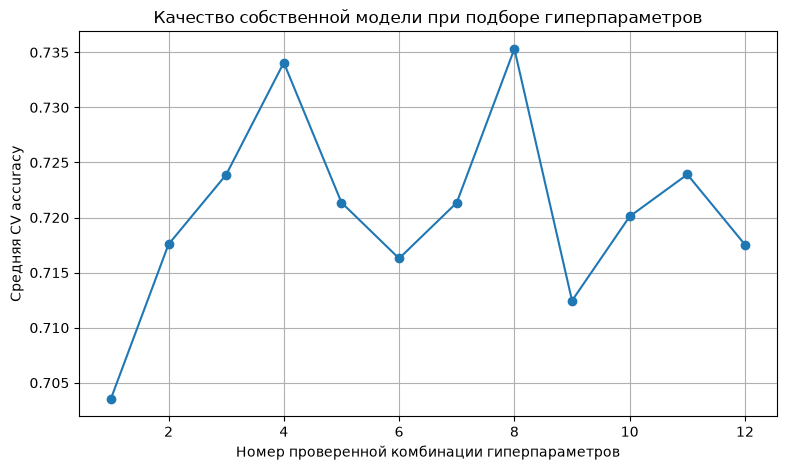

In [33]:
cv_results_my["iteration"] = range(
    1,
    len(cv_results_my) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    cv_results_my["iteration"],
    cv_results_my["mean_cv_accuracy"],
    marker="o"
)

plt.xlabel("Номер проверенной комбинации гиперпараметров")
plt.ylabel("Средняя CV accuracy")
plt.title("Качество собственной модели при подборе гиперпараметров")
plt.grid()

plt.show()

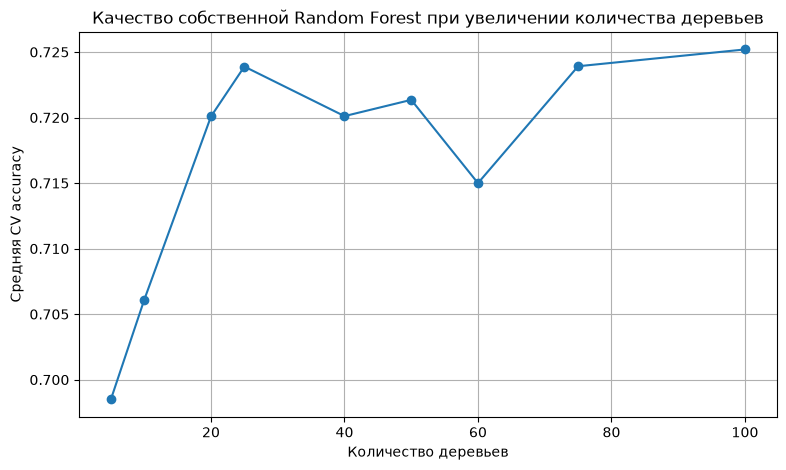

In [34]:
n_trees = [5, 10, 20, 25, 40, 50, 60, 75, 100]

tree_scores = []

for n in n_trees:

    score = my_cv_accuracy(
        n_estimators=n,
        max_depth=10
    )

    tree_scores.append(score)


plt.figure(figsize=(9, 5))

plt.plot(
    n_trees,
    tree_scores,
    marker="o"
)

plt.xlabel("Количество деревьев")
plt.ylabel("Средняя CV accuracy")
plt.title(
    "Качество собственной Random Forest "
    "при увеличении количества деревьев"
)
plt.grid()

plt.show()

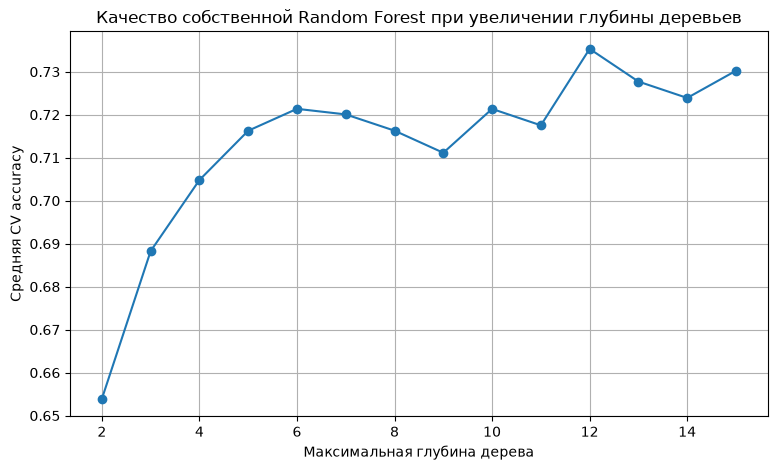

In [35]:
depths = range(2, 16)

depth_scores = []

for depth in depths:

    score = my_cv_accuracy(
        n_estimators=50,
        max_depth=depth
    )

    depth_scores.append(score)


plt.figure(figsize=(9, 5))

plt.plot(
    depths,
    depth_scores,
    marker="o"
)

plt.xlabel("Максимальная глубина дерева")
plt.ylabel("Средняя CV accuracy")
plt.title(
    "Качество собственной Random Forest "
    "при увеличении глубины деревьев"
)
plt.grid()

plt.show()

**Сравнение собственной модели с моделью из sklearn**

Для итогового сравнения используются одинаковые метрики качества для модели `RandomForestClassifier` из библиотеки `sklearn` и собственной реализации Random Forest

In [36]:
comparison = pd.DataFrame({
    "sklearn": [
        results.loc["Train", "Accuracy"],
        results.loc["Validation", "Accuracy"],
        results.loc["Test", "Accuracy"],
        results.loc["Test", "Precision"],
        results.loc["Test", "Recall"],
        results.loc["Test", "F1"]
    ],
    "Собственная модель": [
        my_results.loc["Train", "Accuracy"],
        my_results.loc["Validation", "Accuracy"],
        my_results.loc["Test", "Accuracy"],
        my_results.loc["Test", "Precision"],
        my_results.loc["Test", "Recall"],
        my_results.loc["Test", "F1"]
    ]
}, index=[
    "Train Accuracy",
    "Validation Accuracy",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
])

comparison.round(3)

,sklearn,Собственная модель
Train Accuracy,0.800,0.818
Validation Accuracy,0.751,0.787
Test Accuracy,0.728,0.716
Test Precision,0.750,0.755
Test Recall,0.781,0.740
Test F1,0.765,0.747


**Итоговое сравнение**

Качество собственной реализации Random Forest оказалось близким к качеству модели `RandomForestClassifier` из `sklearn`.
Собственная реализация демонстрирует сопоставимое качество с библиотечной моделью. Небольшие различия связаны с более простой реализацией алгоритма и особенностями построения случайных деревьев